# Phase 1.3 — dubins controller synthesis + verification

Reads the Phase 1.2 outputs (per-channel effective bound `u_max_eff` and the
kept sample subset), runs the **hard** bounded-control SOP
(`solve_dubins.m`), and verifies the exported closed-form controller:

1. **bound realization** — $|u_i(\bm x)|\le u_{\max,i}^{\rm eff}$ over the
   reach-avoid set;
2. **reach-avoid set** — visualize $\{\bm x: V(\bm x)\ge 0\}$ from samples;
3. **closed-form rollout** — integrate $\dot{\bm x}=f+g\,u(\bm x)$ from one
   sample and confirm it enters the target while staying safe and admissible.

Self-contained: imports `synth_lib` (revision/controller_synthesis), reads the
exported controller from revision/controllers/, writes to revision/data/.


## §1 — Bootstrap (paths, system, Phase 1.1/1.2 inputs)


In [10]:
import importlib.util
import json
import os
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# locate ROOT via revision/matlab_frozen (no reference to the main repo)
ROOT = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.isdir(os.path.join(ROOT, "revision", "matlab_frozen")):
        break
    ROOT = os.path.dirname(ROOT)
REV = os.path.join(ROOT, "revision")
FROZEN = os.path.join(REV, "matlab_frozen")
CSYN = os.path.join(REV, "controller_synthesis")
CTRL = os.path.join(REV, "controllers")
REV_DATA = os.path.join(REV, "data")
MATLAB_BIN = shutil.which("matlab") or "/usr/local/bin/matlab"

sys.path.insert(0, CSYN)
import synth_lib  # noqa: E402

EXAMPLE = "dubins"

# --- selected operating point from the slack_weight sweep (dubins_slack_diag) ---
# The sweep produces, per slack_weight, the effective bound u_max_eff + kept subset
# + corrected funnel. Pick ONE weight here; it sets U_MAX_EFF for the §3 gate AND is
# passed to solve_dubins.m (via env) so the synthesis uses the SAME weight.
CHOSEN_SLACK_WEIGHT = 0.001

# Phase 1.1 synthesis region X_S_eff (sampling box)
with open(os.path.join(REV_DATA, f"phase1_1_outputs_{EXAMPLE}.json")) as fh:
    p11 = json.load(fh)
# per-channel effective bound for the chosen weight, from the sweep summary
_sweep = pd.read_csv(os.path.join(REV_DATA, f"sweep_summary_{EXAMPLE}.csv"))
_row = _sweep[
    np.isclose(_sweep["slack_weight"], CHOSEN_SLACK_WEIGHT, rtol=1e-9, atol=0.0)
]
if _row.empty:
    raise FileNotFoundError(
        f"slack_weight={CHOSEN_SLACK_WEIGHT} not in sweep_summary_{EXAMPLE}.csv -- "
        f"run the {EXAMPLE}_slack_diag sweep first."
    )
_row = _row.iloc[0]

SYS = synth_lib.dubins_system()
CHANNELS = SYS["channels"]
U_MAX_EFF = [float(_row[f"u_max_eff_{ch}"]) for ch in CHANNELS]
dim = len(SYS["state"])
LO = np.array(p11["X_S_eff_def"]["lower"], float)[:dim]
HI = np.array(p11["X_S_eff_def"]["upper"], float)[:dim]


def run_matlab(script_name, env_overrides=None):
    """Run a revision MATLAB driver (frozen + controller_synthesis on path),
    streaming stdout live with an elapsed-time prefix. env_overrides -> ENV vars."""
    env = os.environ.copy()
    if env_overrides:
        env.update({k: str(v) for k, v in env_overrides.items()})
    cmd = [
        MATLAB_BIN,
        "-batch",
        f"addpath('{FROZEN}'); addpath('{CSYN}'); "
        f"try, {script_name}; catch e, disp(getReport(e)); exit(1); end; exit(0);",
    ]
    t0 = time.time()
    proc = subprocess.Popen(
        cmd,
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    lines = []
    for raw in proc.stdout:
        line = raw.rstrip()
        lines.append(line)
        print(f"[matlab +{time.time() - t0:6.0f}s] {line}")
        sys.stdout.flush()
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(f"MATLAB {script_name} failed (rc={proc.returncode})")


print("EXAMPLE  :", EXAMPLE)
print("slack_weight (selected):", CHOSEN_SLACK_WEIGHT)
print("channels :", CHANNELS)
print("u_max_eff:", dict(zip(CHANNELS, U_MAX_EFF)))
print("X_S_eff lo:", LO)
print("X_S_eff hi:", HI)

EXAMPLE  : dubins
slack_weight (selected): 0.001
channels : ['omega', 'a']
u_max_eff: {'omega': 7.9, 'a': 5.1}
X_S_eff lo: [-2.        -2.         2.0943951  0.1      ]
X_S_eff hi: [2.        2.        4.1887902 1.       ]


## §2 — Synthesize the controller (hard SOP) and load it

Triggers `solve_dubins.m` if the exported controller is missing (set
`REGENERATE=True` to force). Imports the sympy controller + certificate and
builds the closed-loop / set callables via `synth_lib`.


In [11]:
# solve_<ex>.m synthesizes BOTH controllers at the SELECTED slack_weight: the
# constrained hard-SOP controller and the unconstrained vanilla-k1 baseline. "cb"
# is the constrained one used by the §3 gate / §4 RA-set / §5 rollout; cb_unc is
# the §5b baseline. CHOSEN_SLACK_WEIGHT (§1) is passed to solve_<ex>.m via env so
# the synthesis matches U_MAX_EFF, and we re-synthesize if the cached controllers
# were built at a different weight.
REGENERATE = False
con_path = os.path.join(CTRL, f"{EXAMPLE}_constrained.py")
unc_path = os.path.join(CTRL, f"{EXAMPLE}_unconstrained.py")
meta_path = os.path.join(REV_DATA, f"phase1_3_meta_{EXAMPLE}.json")

need = REGENERATE or not (os.path.exists(con_path) and os.path.exists(unc_path))
if not need:
    try:
        _m = json.load(open(meta_path))
        if not np.isclose(
            float(_m.get("slack_weight", np.nan)),
            CHOSEN_SLACK_WEIGHT,
            rtol=1e-9,
            atol=0.0,
        ):
            need = True
            print(
                f"cached controllers are slack_weight={_m.get('slack_weight')} != {CHOSEN_SLACK_WEIGHT} -> re-synthesize"
            )
    except Exception:
        need = True

if need:
    print(
        f"running solve_{EXAMPLE}.m (MATLAB, slack_weight={CHOSEN_SLACK_WEIGHT}) -- live stage output below ..."
    )
    run_matlab(f"solve_{EXAMPLE}", {"CHOSEN_SLACK_WEIGHT": CHOSEN_SLACK_WEIGHT})
    print("MATLAB synthesis finished.")
else:
    print(
        f"controllers exist at slack_weight={CHOSEN_SLACK_WEIGHT}:\n  {con_path}\n  {unc_path}\n(set REGENERATE=True to re-synthesize)"
    )


def _load(path):
    spec = importlib.util.spec_from_file_location(os.path.basename(path)[:-3], path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


# constrained controller (the one verified by §3-§5); keep names cb / ctrl / py_path
ctrl = _load(con_path)
py_path = con_path
cb = synth_lib.make_callables(SYS, ctrl.u_opt, ctrl.certificate_opt)
# unconstrained baseline for the §5b comparison
ctrl_unc = _load(unc_path)
cb_unc = synth_lib.make_callables(SYS, ctrl_unc.u_opt, ctrl_unc.certificate_opt)
print(f"loaded constrained + unconstrained controllers ({len(ctrl.u_opt)} inputs each)")

running solve_dubins.m (MATLAB, slack_weight=0.001) -- live stage output below ...
[matlab +     4s] solve_dubins: slack_weight=0.001 (selected) -> mu=0.1 xi0=1e-08 ds=4 dv=4 lambda=1.09456e-08  u_max_eff=[omega 7.9, a 5.1]
[matlab +     4s]   loaded 187 kept samples for slack_weight=0.001
[matlab +     5s] [stage] backstepping design done in 0.3s; solving vanilla k1 ...
[matlab +     6s] Size: 1432   152
[matlab +     6s] 
[matlab +     6s] TBB Warning: The number of workers is currently limited to 5. The request for 9 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.
[matlab +     6s] 
[matlab +     6s] 
[matlab +     6s] MOSEK Version 11.0.12 (Build date: 2025-3-13 07:41:24)
[matlab +     6s] Copyright (c) MOSEK ApS, Denmark WWW: mosek.com
[matlab +     6s] Platform: Linux/64-X86
[matlab +     6s] 
[matlab +     6s] Problem
[matlab +     6s]   Name                   :
[matlab +     6s]   Objective sense        : minimize
[matlab 

## §3 — Bound realization over the reach-avoid set

Dense, independent sample of $\mathcal X_S^{\rm eff}$; restrict to the
reach-avoid set ($V\ge 0$, safe, outside target) and check
$\max|u_i|\le u_{\max,i}^{\rm eff}$. The hard SOP enforces the bound only at
the kept sample points, so this verifies generalization to the whole set.


In [12]:
N_CHECK = 100_000
Xc = synth_lib.sample_box(LO, HI, N_CHECK, seed=20260531)
V, safe, target, _ = synth_lib.evaluate(cb, Xc)
in_ra = (V >= 0) & (safe >= 0) & (target >= 0)  # V>=0, safe, outside target
Xra = Xc[in_ra]
bound_realized = False  # set True below iff |u| <= u_max_eff over the RA set
print(f"{in_ra.sum()} / {N_CHECK} dense samples lie in the reach-avoid set")
if Xra.shape[0] == 0:
    print("WARNING: no samples in the reach-avoid set -- check the box / certificate.")
else:
    _, _, _, Ura = synth_lib.evaluate(cb, Xra)
    all_ok = True
    for k, ch in enumerate(CHANNELS):
        au = np.abs(Ura[k])
        mx = float(au.max())
        ok = mx <= U_MAX_EFF[k] * (1 + 1e-3)
        all_ok = all_ok and ok
        bound_realized = all_ok
        print(
            f"  |u_{ch}|: max={mx:.4g}  p99={np.percentile(au,99):.4g}  "
            f"p99.9={np.percentile(au,99.9):.4g}   (u_max_eff={U_MAX_EFF[k]:.4g})  "
            f"-> {'PASS' if ok else 'EXCEEDS'}"
        )
    print(
        "VERDICT:",
        (
            "bound realized over the RA set"
            if all_ok
            else "exceeds on the dense set (SOP enforces bounds only at sampled points)"
        ),
    )

37460 / 100000 dense samples lie in the reach-avoid set
  |u_omega|: max=99.58  p99=37.3  p99.9=67.23   (u_max_eff=7.9)  -> EXCEEDS
  |u_a|: max=10.75  p99=7.541  p99.9=9.668   (u_max_eff=5.1)  -> EXCEEDS
VERDICT: exceeds on the dense set (SOP enforces bounds only at sampled points)


## §4 — Reach-avoid set visualization (from samples)

Samples of $\mathcal X_S^{\rm eff}$ coloured by the certificate sign: the
reach-avoid set is $\{V\ge 0\}$. Shown over the two state projections and in
the output/workspace $(y_1,y_2)=h(\bm x)$ with the safe/target boundaries.


reach-avoid set: V>=0 on 15028 of 17054 safe-and-outside-target samples (88.1%)


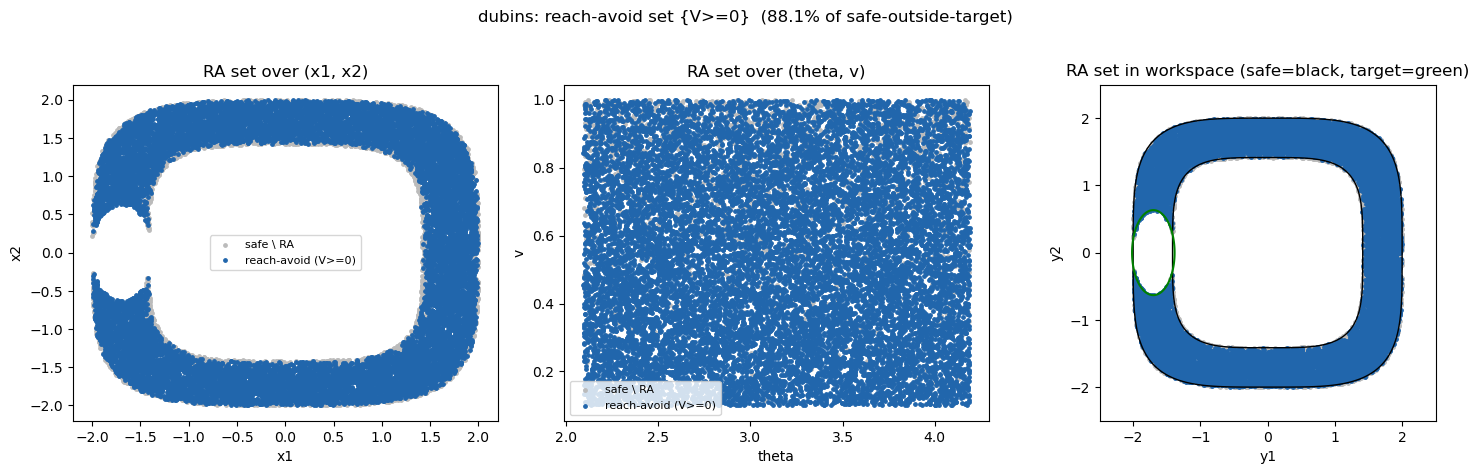

In [13]:
import sympy as sp

N_VIZ = 40_000
Xv = synth_lib.sample_box(LO, HI, N_VIZ, seed=7)
V, safe, target, _ = synth_lib.evaluate(cb, Xv)
cand = (safe >= 0) & (target >= 0)  # safe and outside target
ra = cand & (V >= 0)  # reach-avoid set
Y = np.array(cb["h"](*Xv.T)).reshape(2, -1)  # workspace coords (2, N)
frac = ra.sum() / max(cand.sum(), 1)
print(
    f"reach-avoid set: V>=0 on {ra.sum()} of {cand.sum()} safe-and-outside-target "
    f"samples ({100*frac:.1f}%)"
)

proj = SYS["proj"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (i, jx, lx, ly) in zip(axes[:2], proj):
    ax.scatter(
        Xv[cand & ~ra, i], Xv[cand & ~ra, jx], s=6, c="#bbbbbb", label="safe \\ RA"
    )
    ax.scatter(Xv[ra, i], Xv[ra, jx], s=6, c="#2166ac", label="reach-avoid (V>=0)")
    ax.set_xlabel(lx)
    ax.set_ylabel(ly)
    ax.legend(fontsize=8)
    ax.set_title(f"RA set over ({lx}, {ly})")

# workspace panel with safe/target boundaries
ax = axes[2]
ax.scatter(Y[0, cand & ~ra], Y[1, cand & ~ra], s=6, c="#bbbbbb")
ax.scatter(Y[0, ra], Y[1, ra], s=6, c="#2166ac")
y1s, y2s = SYS["y"]
safe_f = sp.lambdify((y1s, y2s), SYS["safe_y"], "numpy")
targ_f = sp.lambdify((y1s, y2s), SYS["target_y"], "numpy")
gy1 = np.linspace(Y[0].min() - 0.5, Y[0].max() + 0.5, 300)
gy2 = np.linspace(Y[1].min() - 0.5, Y[1].max() + 0.5, 300)
GY1, GY2 = np.meshgrid(gy1, gy2)
ax.contour(GY1, GY2, safe_f(GY1, GY2), levels=[0], colors="k", linewidths=1)
ax.contour(GY1, GY2, targ_f(GY1, GY2), levels=[0], colors="g", linewidths=1.5)
ax.set_xlabel("y1")
ax.set_ylabel("y2")
ax.set_aspect("equal")
ax.set_title("RA set in workspace (safe=black, target=green)")
fig.suptitle(
    f"{EXAMPLE}: reach-avoid set {{V>=0}}  ({100*frac:.1f}% of safe-outside-target)",
    y=1.02,
)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, f"phase1_3_ra_set_{EXAMPLE}.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

## §4b — Constrained control law vector field in output space

The synthesis exports the virtual control law $k_1(\bm y)$ in the
output/workspace coordinates $\bm y=(y_1,y_2)=h(\bm x)$: the desired output
velocity $\dot{\bm y}=k_1(\bm y)$ that the full state feedback $u(\bm x)$ is
constructed to realize. Its streamlines (coloured by $\|k_1(\bm y)\|$) over the
safe/target sets show how the **constrained** law steers the output into
$\mathcal X_T$ while keeping it inside $\mathcal X_S$. Plotting follows
`experiments/make_paper_figs_dubins.ipynb` (§5: `_k1_field` + `streamplot`).


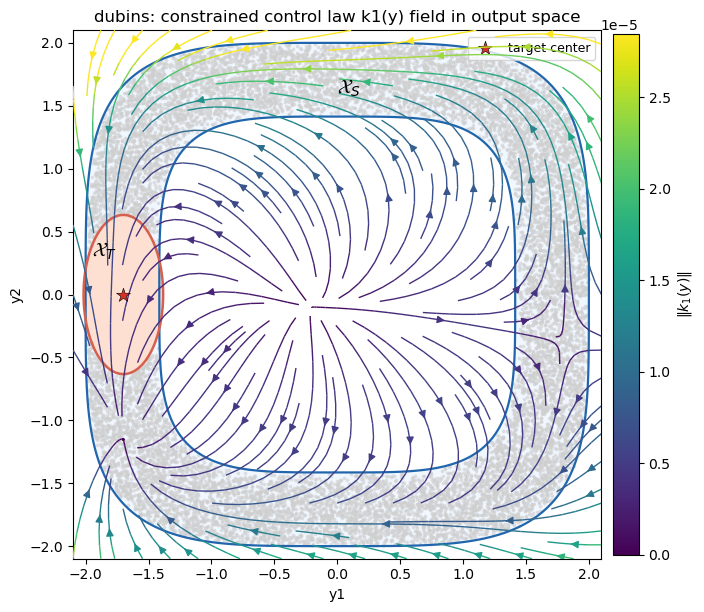

k1(y) field over [-2.1,2.1]^2: speed min=6.75e-08 median=6.67e-06 max=4.71e-05


In [14]:
# The synthesis exports k1(y): the constrained virtual control law expressed in
# the output coordinates y=(y1,y2)=h(x). This IS the control law's vector field
# in output space -- the desired output velocity ydot = k1(y) that the full
# state feedback u(x) is built to realize. (k1_opt is a 2-vector of polynomials
# in y1,y2, so the field is smooth everywhere, unlike u_opt's 1/det(A) form.)
# Plotting follows experiments/make_paper_figs_dubins.ipynb (§5: _k1_field +
# streamplot). The unconstrained vanilla-k1 field is shown for contrast in §4c
# (it is numerically ~0, coeffs ~1e-7, and does not steer toward the target).
y1s, y2s = SYS["y"]
k1_f = sp.lambdify((y1s, y2s), list(ctrl.k1_opt), "numpy")

# output-space window + dense set grids (reuse §4 safe_f/targ_f); ref window [-2.1, 2.1]
ylo, yhi = -2.1, 2.1
gg = np.linspace(ylo, yhi, 400)
SG1, SG2 = np.meshgrid(gg, gg)
Zs = safe_f(SG1, SG2)
Zt = targ_f(SG1, SG2)
# coarser regular grid for the streamplot
n_vf = 32
g1 = np.linspace(ylo, yhi, n_vf)
g2 = np.linspace(ylo, yhi, n_vf)
VG1, VG2 = np.meshgrid(g1, g2)
_vals = k1_f(VG1, VG2)
Uk = np.broadcast_to(np.asarray(_vals[0], float), VG1.shape).astype(float)
Vk = np.broadcast_to(np.asarray(_vals[1], float), VG1.shape).astype(float)
speed = np.sqrt(Uk**2 + Vk**2)

fig, ax = plt.subplots(figsize=(7.0, 6.4))
ax.contourf(SG1, SG2, Zs, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.6, zorder=1)
ax.contour(SG1, SG2, Zs, levels=[0], colors=["#2166ac"], linewidths=1.6, zorder=4)
ax.contourf(SG1, SG2, Zt, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=2)
ax.contour(SG1, SG2, Zt, levels=[0], colors=["#d6604d"], linewidths=1.8, zorder=5)
# light reach-avoid sample cloud (from §4) for context
ax.scatter(Y[0, ra], Y[1, ra], s=3, c="#cfcfcf", alpha=0.5, zorder=3)
vmax = float(np.nanpercentile(speed, 95)) or 1.0
strm = ax.streamplot(
    g1,
    g2,
    Uk,
    Vk,
    color=speed,
    cmap="viridis",
    norm=plt.Normalize(0.0, vmax),
    linewidth=1.0,
    density=1.3,
    arrowsize=1.1,
    zorder=6,
)
fig.colorbar(strm.lines, ax=ax, fraction=0.046, pad=0.02, label=r"$\|k_1(y)\|$")
ax.scatter(
    -1.7,
    0.0,
    s=110,
    marker="*",
    c="#d73027",
    edgecolors="k",
    linewidths=0.4,
    zorder=10,
    label="target center",
)
ax.text(0.0, 1.6, r"$\mathcal{X}_S$", fontsize=14, zorder=20)
ax.text(-1.95, 0.3, r"$\mathcal{X}_T$", fontsize=14, zorder=20)
ax.set_xlabel("y1")
ax.set_ylabel("y2")
ax.set_xlim(ylo, yhi)
ax.set_ylim(ylo, yhi)
ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=9)
ax.set_title(f"{EXAMPLE}: constrained control law k1(y) field in output space")
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, f"phase1_3_vecfield_{EXAMPLE}.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()
print(
    f"k1(y) field over [{ylo},{yhi}]^2: speed min={speed.min():.3g} "
    f"median={np.median(speed):.3g} max={speed.max():.3g}"
)

## §4c — Unconstrained (vanilla-$k_1$) control law vector field

The same output-space view as §4b, for the **unconstrained vanilla-$k_1$**
baseline. The baseline does not optimize $k_1$ for reach-avoid, so its exported
$k_1(\bm y)$ is numerically $\approx 0$ (coefficients $\sim 10^{-7}$, about
$10^6\times$ smaller than the constrained field) and its direction does **not**
coherently steer toward $\mathcal X_T$ — the unconstrained controller's
reaching is produced by the full backstepping law $u(\bm x)$, not by $k_1$. The
streamlines (scale-invariant geometry) and the colour bar (this field's own
tiny scale) make the contrast with §4b explicit.


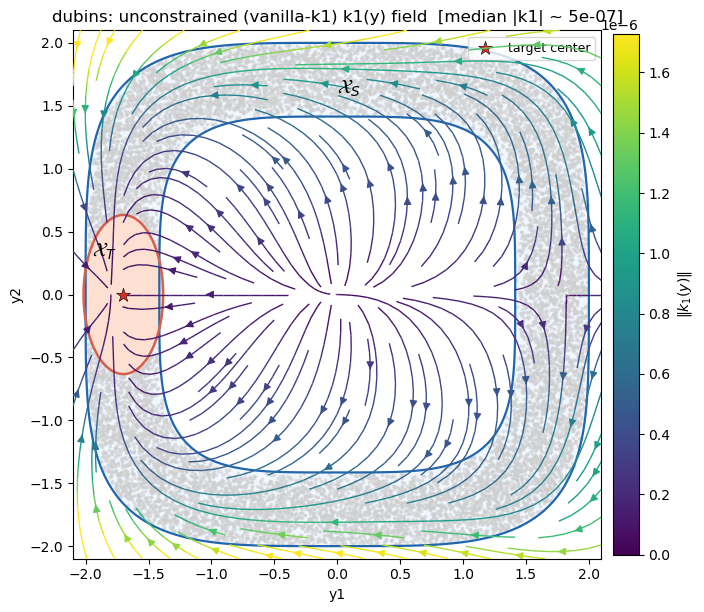

unconstrained k1(y) field: speed min=2.02e-08 median=4.93e-07 max=2.56e-06  (constrained median ~0.46, i.e. ~9e+05x larger)


In [15]:
# Same output-space window/sets/grid as §4b (reused), now for the UNCONSTRAINED
# vanilla-k1 law. Unlike the constrained synthesis, the vanilla baseline does
# not optimize k1 for reach-avoid: its exported k1(y) is numerically ~0 (coeffs
# ~1e-7, ~1e6x smaller than §4b) and its direction does NOT coherently steer
# toward the target -- the unconstrained controller's reaching is produced by
# the full backstepping law u_opt, not by k1. Streamlines show the (scale-
# invariant) direction field; colour uses this field's OWN tiny scale (colorbar).
k1u_f = sp.lambdify((y1s, y2s), list(ctrl_unc.k1_opt), "numpy")
_valsu = k1u_f(VG1, VG2)
Uu = np.broadcast_to(np.asarray(_valsu[0], float), VG1.shape).astype(float)
Vu = np.broadcast_to(np.asarray(_valsu[1], float), VG1.shape).astype(float)
speed_u = np.sqrt(Uu**2 + Vu**2)

fig, ax = plt.subplots(figsize=(7.0, 6.4))
ax.contourf(SG1, SG2, Zs, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.6, zorder=1)
ax.contour(SG1, SG2, Zs, levels=[0], colors=["#2166ac"], linewidths=1.6, zorder=4)
ax.contourf(SG1, SG2, Zt, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=2)
ax.contour(SG1, SG2, Zt, levels=[0], colors=["#d6604d"], linewidths=1.8, zorder=5)
# light reach-avoid sample cloud (from §4) for context
ax.scatter(Y[0, ra], Y[1, ra], s=3, c="#cfcfcf", alpha=0.5, zorder=3)
vmax_u = float(np.nanpercentile(speed_u, 95)) or 1.0
strm = ax.streamplot(
    g1,
    g2,
    Uu,
    Vu,
    color=speed_u,
    cmap="viridis",
    norm=plt.Normalize(0.0, vmax_u),
    linewidth=1.0,
    density=1.3,
    arrowsize=1.1,
    zorder=6,
)
fig.colorbar(strm.lines, ax=ax, fraction=0.046, pad=0.02, label=r"$\|k_1(y)\|$")
ax.scatter(
    -1.7,
    0.0,
    s=110,
    marker="*",
    c="#d73027",
    edgecolors="k",
    linewidths=0.4,
    zorder=10,
    label="target center",
)
ax.text(0.0, 1.6, r"$\mathcal{X}_S$", fontsize=14, zorder=20)
ax.text(-1.95, 0.3, r"$\mathcal{X}_T$", fontsize=14, zorder=20)
ax.set_xlabel("y1")
ax.set_ylabel("y2")
ax.set_xlim(ylo, yhi)
ax.set_ylim(ylo, yhi)
ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=9)
ax.set_title(
    f"{EXAMPLE}: unconstrained (vanilla-k1) k1(y) field  "
    f"[median |k1| ~ {np.median(speed_u):.0e}]"
)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, f"phase1_3_vecfield_{EXAMPLE}_unconstrained.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()
print(
    f"unconstrained k1(y) field: speed min={speed_u.min():.3g} "
    f"median={np.median(speed_u):.3g} max={speed_u.max():.3g}  "
    f"(constrained median ~0.46, i.e. ~{0.46 / max(np.median(speed_u), 1e-30):.0e}x larger)"
)

## §5 — Closed-form rollout from one reach-avoid sample

Pick a representative start inside the reach-avoid set (input-admissible, far
from the target), integrate $\dot{\bm x}=f+g\,u(\bm x)$ with the exported
control law, and confirm it enters the target while staying safe and within
the per-channel bounds.


rollout start x0 = [1.8103 1.373  2.4118 0.9232]  (trial-rollout pick; good on candidate 8 of 11388)
  steps=3580  reached=True  stayed_safe=True  stop=reached_target
  max|u_omega| along trajectory = 5.496  (u_max_eff=7.9)
  max|u_a| along trajectory = 2.653  (u_max_eff=5.1)


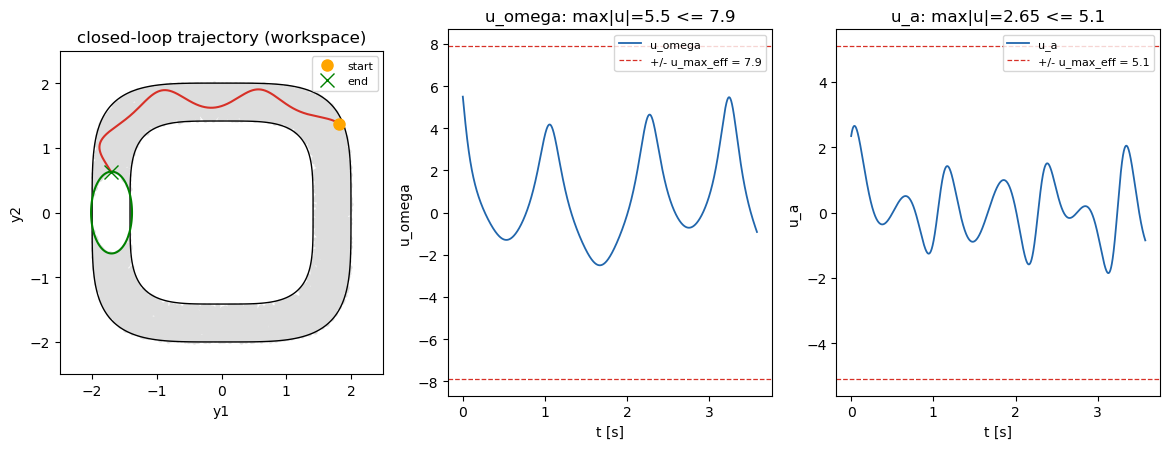

In [16]:
# Start selection by TRIAL ROLLOUT (a good start is one whose *trajectory*
# keeps the FL coordinate bounded -- Dubins v, manipulator sin(q2); a static
# deepest-V / farthest-from-target heuristic cannot see that and often picks a
# start from which the 1/det(A) law saturates). We therefore scan admissible
# reach-avoid candidates, ordered farthest-from-target (informative, long
# trajectory first), and keep the first whose rollout reaches the target while
# staying safe and within u_max_eff.
cand_idx = np.where(ra)[0]
Xs = Xv[cand_idx]
_, _, _, Us = synth_lib.evaluate(cb, Xs)
adm = np.all([np.abs(Us[k]) <= U_MAX_EFF[k] for k in range(len(CHANNELS))], axis=0)
Xa = Xs[adm] if adm.sum() else Xs
tcx, tcy = (5.5, 1.8) if EXAMPLE == "manipulator" else (-1.7, 0.0)
Ya = np.array(cb["h"](*Xa.T)).reshape(2, -1)
order = np.argsort(-((Ya[0] - tcx) ** 2 + (Ya[1] - tcy) ** 2))  # far -> near


def _good(r):
    within = bool(
        np.all(
            [
                r["max_abs_u"][k] <= U_MAX_EFF[k] * (1 + 1e-3)
                for k in range(len(CHANNELS))
            ]
        )
    )
    return bool(r["reached"] and r["stayed_safe"] and within), within


MAX_TRIALS = 300  # cap the search; good starts are common (~25-30%)
x0, sel_trials = None, 0
for _i in order[:MAX_TRIALS]:
    sel_trials += 1
    _r = synth_lib.simulate(SYS, cb, Xa[_i])  # default integrator for the search
    _ok, _ = _good(_r)
    if _ok:
        x0 = Xa[_i]
        break
if x0 is None:
    # no fully-good start found: fall back to the farthest admissible one and
    # let the gate (§6) flag REVIEW so the failure is explicit, not hidden.
    x0 = Xa[order[0]]
    print(
        f"WARNING: no good rollout among {sel_trials} candidates; "
        f"using farthest admissible start (rollout will be flagged in §6)."
    )
else:
    print(
        f"rollout start x0 = {np.round(x0, 4)}  "
        f"(trial-rollout pick; good on candidate {sel_trials} of {len(order)})"
    )

res = synth_lib.simulate(SYS, cb, x0, dt=0.001)
X = res["X"]
Yt = np.array(cb["h"](*X.T)).reshape(2, -1)
print(
    f"  steps={len(res['t'])}  reached={res['reached']}  stayed_safe={res['stayed_safe']}  "
    f"stop={res['stop_reason']}"
)
for k, ch in enumerate(CHANNELS):
    print(
        f"  max|u_{ch}| along trajectory = {res['max_abs_u'][k]:.4g}  (u_max_eff={U_MAX_EFF[k]:.4g})"
    )

# workspace trajectory + ONE control subplot PER CHANNEL (the channels have
# different effective bounds, e.g. Dubins omega/a = 7.7/5.1, manipulator
# tau1/tau2 ~ 679/500, so a shared axis with a single bound is misleading).
m = len(CHANNELS)
fig, axes = plt.subplots(1, 1 + m, figsize=(5.0 + 3.4 * m, 4.6))
ax = axes[0]
ax.scatter(Y[0, ra], Y[1, ra], s=4, c="#dddddd")
ax.contour(GY1, GY2, safe_f(GY1, GY2), levels=[0], colors="k", linewidths=1)
ax.contour(GY1, GY2, targ_f(GY1, GY2), levels=[0], colors="g", linewidths=1.5)
ax.plot(Yt[0], Yt[1], "-", c="#d73027", lw=1.5)
ax.plot(Yt[0, 0], Yt[1, 0], "o", c="orange", ms=8, label="start")
ax.plot(Yt[0, -1], Yt[1, -1], "x", c="green", ms=10, label="end")
ax.set_xlabel("y1")
ax.set_ylabel("y2")
ax.set_aspect("equal")
ax.legend(fontsize=8)
ax.set_title("closed-loop trajectory (workspace)")

for k, ch in enumerate(CHANNELS):
    ax = axes[1 + k]
    ax.plot(res["t"], res["U"][k], c="#2166ac", lw=1.3, label=f"u_{ch}")
    ax.axhline(
        U_MAX_EFF[k],
        color="#d73027",
        ls="--",
        lw=0.9,
        label=f"+/- u_max_eff = {U_MAX_EFF[k]:g}",
    )
    ax.axhline(-U_MAX_EFF[k], color="#d73027", ls="--", lw=0.9)
    peak = float(res["max_abs_u"][k])
    ok = peak <= U_MAX_EFF[k] * (1 + 1e-3)
    ax.set_xlabel("t [s]")
    ax.set_ylabel(f"u_{ch}")
    ax.legend(fontsize=8)
    ax.set_title(f"u_{ch}: max|u|={peak:.3g} {'<=' if ok else '>'} {U_MAX_EFF[k]:g}")
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, f"phase1_3_rollout_{EXAMPLE}.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

## §5b — Constrained vs. unconstrained from the same start

Both controllers share the same backstepping certificate at the same
$(\mu,\lambda)$; the only difference is that the constrained one was solved
with hard per-sample input limits while the unconstrained vanilla-$k_1$
baseline ignores them. Rolling both out from the SAME start $x_0$ shows the
trade-off: the unconstrained law typically reaches faster but with much larger
$|u_i|$, while the constrained law respects (or is closer to) $u_{\max}^{\rm eff}$.


constrained vs unconstrained from the same x0 = [1.8103 1.373  2.4118 0.9232]
  constrained  : reached=True safe=True stop=reached_target  |u_omega|<=5.5, |u_a|<=2.65
  unconstrained: reached=True safe=True stop=reached_target  |u_omega|<=5.5, |u_a|<=2.65


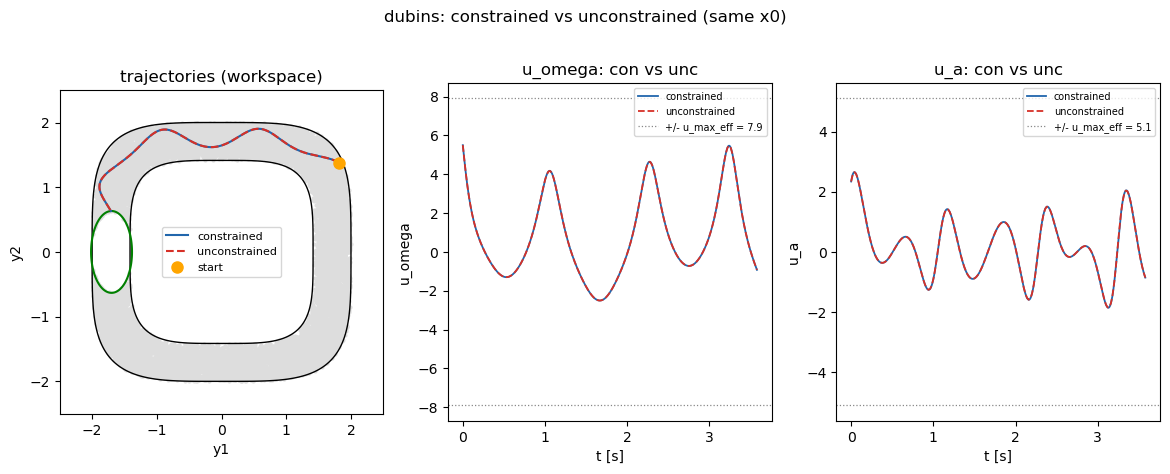

In [17]:
res_unc = synth_lib.simulate(SYS, cb_unc, x0, t_max=20)
print("constrained vs unconstrained from the same x0 =", np.round(x0, 4))
for tag, r in [("constrained", res), ("unconstrained", res_unc)]:
    mu_str = ", ".join(
        f"|u_{ch}|<={r['max_abs_u'][k]:.3g}" for k, ch in enumerate(CHANNELS)
    )
    print(
        f"  {tag:13s}: reached={r['reached']} safe={r['stayed_safe']} "
        f"stop={r['stop_reason']:>14s}  {mu_str}"
    )

Yc = np.array(cb["h"](*res["X"].T)).reshape(2, -1)
Yu = np.array(cb_unc["h"](*res_unc["X"].T)).reshape(2, -1)
m = len(CHANNELS)
fig, axes = plt.subplots(1, 1 + m, figsize=(5.0 + 3.4 * m, 4.6))
ax = axes[0]
ax.scatter(Y[0, ra], Y[1, ra], s=4, c="#dddddd")
ax.contour(GY1, GY2, safe_f(GY1, GY2), levels=[0], colors="k", linewidths=1)
ax.contour(GY1, GY2, targ_f(GY1, GY2), levels=[0], colors="g", linewidths=1.5)
ax.plot(Yc[0], Yc[1], "-", c="#2166ac", lw=1.5, label="constrained")
ax.plot(Yu[0], Yu[1], "--", c="#d73027", lw=1.5, label="unconstrained")
ax.plot(Yc[0, 0], Yc[1, 0], "o", c="orange", ms=8, label="start")
ax.set_xlabel("y1")
ax.set_ylabel("y2")
ax.set_aspect("equal")
ax.legend(fontsize=8)
ax.set_title("trajectories (workspace)")
for k, ch in enumerate(CHANNELS):
    ax = axes[1 + k]
    ax.plot(res["t"], res["U"][k], "-", c="#2166ac", lw=1.3, label="constrained")
    ax.plot(
        res_unc["t"], res_unc["U"][k], "--", c="#d73027", lw=1.3, label="unconstrained"
    )
    ax.axhline(
        U_MAX_EFF[k],
        color="#888888",
        ls=":",
        lw=0.9,
        label=f"+/- u_max_eff = {U_MAX_EFF[k]:g}",
    )
    ax.axhline(-U_MAX_EFF[k], color="#888888", ls=":", lw=0.9)
    ax.set_xlabel("t [s]")
    ax.set_ylabel(f"u_{ch}")
    ax.legend(fontsize=7)
    ax.set_title(f"u_{ch}: con vs unc")
fig.suptitle(f"{EXAMPLE}: constrained vs unconstrained (same x0)", y=1.02)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, f"phase1_3_compare_{EXAMPLE}.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

## §6 — Export Phase 1.3 outputs


In [18]:
within_bounds = bool(
    np.all(
        [res["max_abs_u"][k] <= U_MAX_EFF[k] * (1 + 1e-3) for k in range(len(CHANNELS))]
    )
)
rollout_ok = bool(res["reached"] and res["stayed_safe"] and within_bounds)
# Verdict requires BOTH the dense bound gate (§3) and a clean rollout (§5).
verdict = "PASS" if (bound_realized and rollout_ok) else "REVIEW"
out = {
    "phase": "1.3",
    "example": EXAMPLE,
    "controller_constrained_py": os.path.relpath(con_path, ROOT),
    "controller_unconstrained_py": os.path.relpath(unc_path, ROOT),
    "u_max_eff": dict(zip(CHANNELS, U_MAX_EFF)),
    "bound_realized": bool(bound_realized),
    "ra_fraction_of_safe_outside_target": float(frac),
    "rollout": {
        "x0": [float(v) for v in x0],
        "reached": bool(res["reached"]),
        "stayed_safe": bool(res["stayed_safe"]),
        "within_bounds": within_bounds,
        "stop_reason": res["stop_reason"],
        "max_abs_u": {ch: float(res["max_abs_u"][k]) for k, ch in enumerate(CHANNELS)},
    },
    "verdict": verdict,
    "unconstrained_rollout": {
        "reached": bool(res_unc["reached"]),
        "stayed_safe": bool(res_unc["stayed_safe"]),
        "max_abs_u": {
            ch: float(res_unc["max_abs_u"][k]) for k, ch in enumerate(CHANNELS)
        },
    },
    "notes": (
        "Phase 1.3 synthesizes BOTH a constrained hard-SOP controller and an "
        "unconstrained vanilla-k1 baseline at the same settings. The bound gate + rollout "
        "verdict refer to the constrained controller; the unconstrained one is the "
        "comparison baseline. The constrained .py + u_max_eff + X_S_eff box are the "
        "Phase 2 interface."
    ),
}
out_path = os.path.join(REV_DATA, f"phase1_3_outputs_{EXAMPLE}.json")
with open(out_path, "w") as fh:
    json.dump(out, fh, indent=2)
print(f"wrote {out_path}")
print(json.dumps(out, indent=2))

wrote /home/jianqiang/Downloads/reach_avoid_backstepping_MPC/revision/data/phase1_3_outputs_dubins.json
{
  "phase": "1.3",
  "example": "dubins",
  "controller_constrained_py": "revision/controllers/dubins_constrained.py",
  "controller_unconstrained_py": "revision/controllers/dubins_unconstrained.py",
  "u_max_eff": {
    "omega": 7.9,
    "a": 5.1
  },
  "bound_realized": false,
  "ra_fraction_of_safe_outside_target": 0.8812008912865017,
  "rollout": {
    "x0": [
      1.810297711836773,
      1.372990829955453,
      2.41179099809364,
      0.9231711046856106
    ],
    "reached": true,
    "stayed_safe": true,
    "within_bounds": true,
    "stop_reason": "reached_target",
    "max_abs_u": {
      "omega": 5.49611906523305,
      "a": 2.6528036369253876
    }
  },
  "verdict": "REVIEW",
  "unconstrained_rollout": {
    "reached": true,
    "stayed_safe": true,
    "max_abs_u": {
      "omega": 5.496104627032014,
      "a": 2.6528048594893807
    }
  },
  "notes": "Phase 1.3 synth